# Federated Learning for Image Classification using CNN on MNIST

This notebook implements Federated Learning using CNN and FedAvg on MNIST.

Each client trains locally. Only model weights are sent to the server.

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Federated Training...
Federated Round 1/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Global Model Accuracy: 0.9631
Global Model Loss: 0.1491
Federated Round 2/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Global Model Accuracy: 0.9820
Global Model Loss: 0.0586
Federated Round 3/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Global Model Accuracy: 0.9843
Global Model Loss: 0.0459
Federated Round 4/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Global Model Accuracy: 0.9862
Global Model Loss: 0.0396
Federated Round 5/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Training Client 5
Global Model Accuracy: 0.9894
Global Model Loss: 0.0316


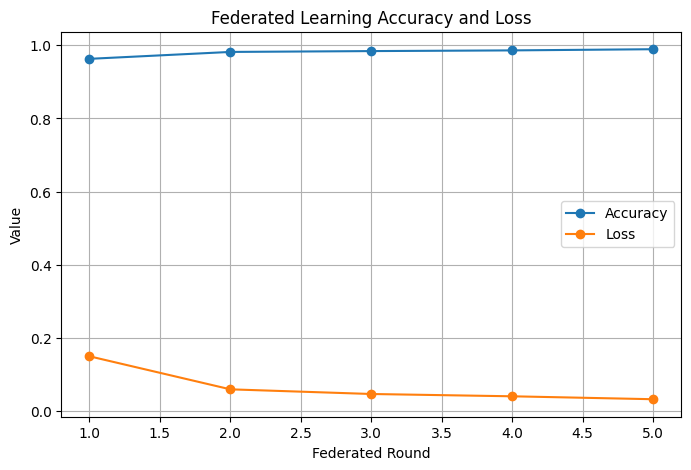

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


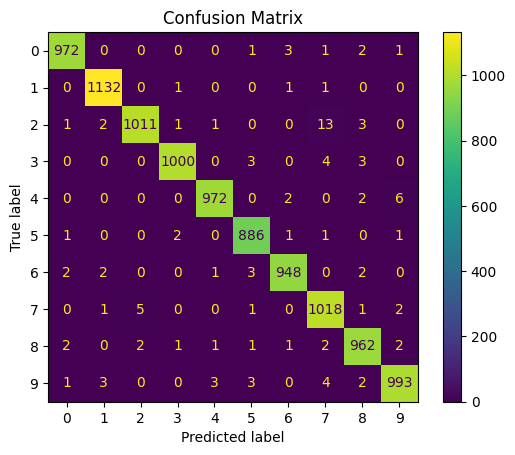

Training completed successfully!
Model saved in: saved_model/federated_mnist_model.h5
Graphs saved in: outputs/


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

def create_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def create_clients(x_train, y_train, num_clients=5):
    client_data = []
    data_per_client = len(x_train) // num_clients

    for i in range(num_clients):
        start = i * data_per_client
        end = start + data_per_client
        client_data.append((x_train[start:end], y_train[start:end]))

    return client_data

def federated_average(client_weights):
    avg_weights = []

    for weights in zip(*client_weights):
        avg_weights.append(np.mean(weights, axis=0))

    return avg_weights

os.makedirs('outputs', exist_ok=True)
os.makedirs('saved_model', exist_ok=True)

NUM_CLIENTS = 5
FEDERATED_ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 32

print('Loading MNIST dataset...')
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

clients = create_clients(x_train, y_train, NUM_CLIENTS)
global_model = create_model()

round_accuracy = []
round_loss = []

print('Starting Federated Training...')

for round_num in range(FEDERATED_ROUNDS):
    print(f'Federated Round {round_num + 1}/{FEDERATED_ROUNDS}')

    client_weights = []

    for client_id, (client_x, client_y) in enumerate(clients):
        print(f'Training Client {client_id + 1}')

        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        local_model.fit(
            client_x,
            client_y,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        client_weights.append(local_model.get_weights())

    new_global_weights = federated_average(client_weights)
    global_model.set_weights(new_global_weights)

    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)
    round_loss.append(loss)
    round_accuracy.append(accuracy)

    print(f'Global Model Accuracy: {accuracy:.4f}')
    print(f'Global Model Loss: {loss:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, FEDERATED_ROUNDS + 1), round_accuracy, marker='o', label='Accuracy')
plt.plot(range(1, FEDERATED_ROUNDS + 1), round_loss, marker='o', label='Loss')
plt.xlabel('Federated Round')
plt.ylabel('Value')
plt.title('Federated Learning Accuracy and Loss')
plt.legend()
plt.grid(True)
plt.savefig('outputs/accuracy_loss.png')
plt.show()

y_pred = global_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.savefig('outputs/confusion_matrix.png')
plt.show()

global_model.save('saved_model/federated_mnist_model.h5')

print('Training completed successfully!')
print('Model saved in: saved_model/federated_mnist_model.h5')
print('Graphs saved in: outputs/')
